# 1. Load dataset
#### For this programming assignment, you are provided with a dataset of handwritten letters and expected to build a CNN model that classifies given image into one of the pre-defined 28 categories. The dataset is provided in two files: train and test sets.
#### You will need to read the data from data files (HandChars32_150_Train.txt and HandChars32_50_Test.txt). The columns are separated by “#” sign. See the description of the columns below:
- PatN – index (label) of image
- PatType – written form of the letter
- PatProb - coefficient of correctness of writing the prototype [0, .., 10].
- SizeH, SizeW – height and width of the image, respectively
- Data – pixels of the grayscale image
#### For building CNN model, you will need to use PatN and Data columns.

In [1]:
import pandas as pd
import numpy as np
data_train =pd.read_table('HandChars32_150_Train.txt', delimiter = '#')
data_test = pd.read_table('HandChars32_50_Test.txt', delimiter = '#')

print(data_train.shape)
print(data_test.shape)

# word_dict = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',
#              10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',
#              18:'S',19:'T',20:'U',21:'V',22:'W',23:'X', 24:'Y',25:'Z'}

(4200, 6)
(1400, 6)


In [2]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   PatN     4200 non-null   int64 
 1   PatType  4200 non-null   int64 
 2   PatProb  4200 non-null   int64 
 3   SizeH    4200 non-null   int64 
 4   SizeW    4200 non-null   int64 
 5   Data     4200 non-null   object
dtypes: int64(5), object(1)
memory usage: 197.0+ KB


In [3]:
data_train.head(3)

,PatN,PatType,PatProb,SizeH,SizeW,Data
0,0,0,10,32,32,0000000000000001100000000000000000000000000000...
1,0,0,10,32,32,0000000000000000001000000000000000000000000000...
2,0,0,10,32,32,0000000000000000000010000000000000000000000000...


In [4]:
data_test.head(3)

,PatN,PatType,PatProb,SizeH,SizeW,Data
0,0,0,10,32,32,0000000000000000000001111000000000000000000000...
1,0,0,10,32,32,0000000000000000000000000000110000000000000000...
2,0,0,10,32,32,0000000000000000110000000000000000000000000000...


In [5]:
print(data_train['PatN'].value_counts())
print("----------------------------------------")
print(data_train['PatType'].value_counts())

0     150
1     150
26    150
25    150
24    150
23    150
22    150
21    150
20    150
19    150
18    150
17    150
16    150
15    150
14    150
13    150
12    150
11    150
10    150
9     150
8     150
7     150
6     150
5     150
4     150
3     150
2     150
27    150
Name: PatN, dtype: int64
----------------------------------------
0    4200
Name: PatType, dtype: int64


In [9]:
len(data_train.iloc[0]['Data'])

1024

In [10]:
lst = []
for i in range(4200):
    x = []
    for j in data_train.iloc[i]['Data']:
        x.append(int(j))
    x = np.array(x)
    lst.append(x)
    
df_train = data_train.assign(data_32_32 = lst)
df_train['data_32_32'] = df_train['data_32_32'].apply(lambda x: x.reshape(32,32))
df_train.head(3)

,PatN,PatType,PatProb,SizeH,SizeW,Data,data_32_32
0,0,0,10,32,32,0000000000000001100000000000000000000000000000...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,0,0,10,32,32,0000000000000000001000000000000000000000000000...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,0,0,10,32,32,0000000000000000000010000000000000000000000000...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [11]:
lst = []
for i in range(1400):
    x = []
    for j in data_test.iloc[i]['Data']:
        x.append(int(j))
    x = np.array(x)
    lst.append(x)
    
    
df_test = data_test.assign(data_32_32 = lst)
df_test['data_32_32'] = df_test['data_32_32'].apply(lambda x: x.reshape(32,32))
df_test.head(3)

,PatN,PatType,PatProb,SizeH,SizeW,Data,data_32_32
0,0,0,10,32,32,0000000000000000000001111000000000000000000000...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,0,0,10,32,32,0000000000000000000000000000110000000000000000...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,0,0,10,32,32,0000000000000000110000000000000000000000000000...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [12]:
print(df_test['data_32_32'][0][4])
print(df_test['data_32_32'][0].shape)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
(32, 32)


In [13]:
x_train = []
for i in range(df_train.shape[0]):
    x_train.append(df_train['data_32_32'][i])
    
x_train = np.array(x_train)
x_train.shape

(4200, 32, 32)

In [14]:
x_test = []
for i in range(df_test.shape[0]):
    x_test.append(df_test['data_32_32'][i])
    
x_test = np.array(x_test)
x_test.shape

(1400, 32, 32)

In [15]:
y_train = []
for i in range(df_train.shape[0]):
    y_train.append(df_train['PatN'][i])
    
y_train = np.array(y_train)
y_train.shape

(4200,)

In [16]:
y_test = []
for i in range(df_test.shape[0]):
    y_test.append(df_test['PatN'][i])
    
y_test = np.array(y_test)
y_test.shape

(1400,)

In [18]:
from keras.utils import to_categorical
train_X = x_train.reshape(x_train.shape[0],x_train.shape[1],x_train.shape[2],1)
test_X = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2],1)
 
train_y = to_categorical(y_train, num_classes = 28, dtype='int')
test_y = to_categorical(y_test, num_classes = 28, dtype='int')

print("The new shape of train data: ", train_X.shape)
print("The new shape of train data: ", test_X.shape)
print("The new shape of train labels: ", train_y.shape)
print("The new shape of test labels: ", test_y.shape)

The new shape of train data:  (4200, 32, 32, 1)
The new shape of train data:  (1400, 32, 32, 1)
The new shape of train labels:  (4200, 28)
The new shape of test labels:  (1400, 28)


# 2. Visualization
#### Visualize some sample images from both train and test sets.

<Figure size 432x288 with 0 Axes>

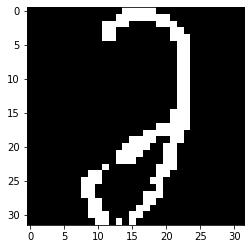

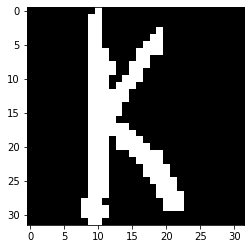

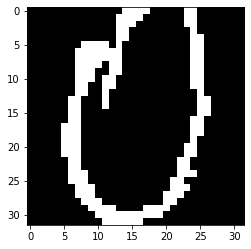

In [19]:
import matplotlib.pyplot as plt
import random as rnd

# Random 3 image from train_set
plt.gray()
for i in range(3):
    random_number = rnd.randint(0,4199)
#     im = df_train["data_32_32"][random_number].reshape(32,32)
    im = df_train["data_32_32"][random_number]
    plt.figure()
    plt.imshow(im)

<Figure size 432x288 with 0 Axes>

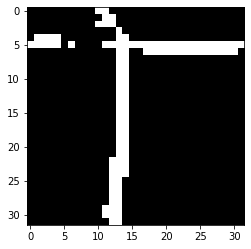

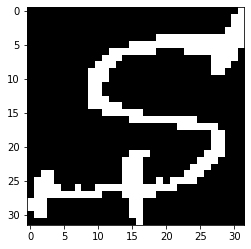

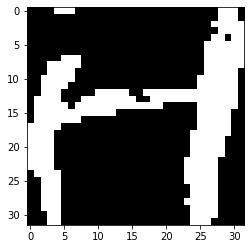

In [20]:
# Random 3 image from train_set
plt.gray()
for i in range(3):
    random_number = rnd.randint(0,1399)
    im = df_test["data_32_32"][random_number]
    plt.figure()
    plt.imshow(im)

# 3. Modeling
#### You are expected to build a convolutional neural network and:
- Train it on the training data
- Perform hyperparameter tuning if needed
- Experiment with different designs (layers, layer units, convolutional layers, pooling layers, filters, filter sizes, padding, epochs, etc.)
- Evaluate the model using test set
- Achieve test accuracy of ~85%
#### You are expected to use tensorflow library. You may need to install it first.
#### You will be using Sequential module from tensoflow.keras. For an example of Sequential model, see the "Tackling Fashion MNIST With a CNN" section of the following notebook:
https://github.com/ageron/handson-ml2/blob/master/14_deep_computer_vision_with_cnns.ipynb
#### You can start with a simple neural network and add convolution and pooling layers as needed.
#### You can choose RMSprop as optimizer, categorical crossentropy as loss, and accuracy as metric.
#### Experiment with different settings.

In [22]:
!pip install tensorflow

In [22]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
from keras.optimizers import SGD, Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [64]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(2, 2), activation='relu', input_shape=(32,32,1)))
model.add(MaxPool2D(pool_size=(2, 2), strides=2))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding = 'same'))
model.add(MaxPool2D(pool_size=(2, 2), strides=2))

model.add(Conv2D(filters=128, kernel_size=(2, 2), activation='relu', padding = 'valid'))
model.add(MaxPool2D(pool_size=(2, 2), strides=2))


model.add(Flatten())
model.add(Dense(512,activation ="relu"))
model.add(Dense(256,activation ="relu"))
model.add(Dense(128,activation ="relu"))
model.add(Dense(64,activation ="relu"))
model.add(Dense(28,activation ="softmax"))

In [65]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_X, train_y, 
                    epochs=10, 
                    batch_size=200, 
                    validation_data = (test_X,test_y))

Epoch 1/10
21/21 [==============================] - 5s 163ms/step - loss: 3.1224 - accuracy: 0.1412 - val_loss: 3.6050 - val_accuracy: 0.0993
Epoch 2/10
21/21 [==============================] - 3s 153ms/step - loss: 1.8023 - accuracy: 0.4850 - val_loss: 1.5616 - val_accuracy: 0.5636
Epoch 3/10
21/21 [==============================] - 3s 148ms/step - loss: 0.8863 - accuracy: 0.7221 - val_loss: 1.7227 - val_accuracy: 0.5543
Epoch 4/10
21/21 [==============================] - 3s 154ms/step - loss: 0.5501 - accuracy: 0.8183 - val_loss: 1.0506 - val_accuracy: 0.7236
Epoch 5/10
21/21 [==============================] - 3s 145ms/step - loss: 0.4221 - accuracy: 0.8667 - val_loss: 0.9941 - val_accuracy: 0.7286
Epoch 6/10
21/21 [==============================] - 3s 146ms/step - loss: 0.3464 - accuracy: 0.8857 - val_loss: 0.8854 - val_accuracy: 0.7750
Epoch 7/10
21/21 [==============================] - 3s 148ms/step - loss: 0.2384 - accuracy: 0.9200 - val_loss: 0.9643 - val_accuracy: 0.7657
Epoch 

In [52]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_21 (Conv2D)          (None, 29, 29, 32)        544       
                                                                 
 max_pooling2d_21 (MaxPoolin  (None, 14, 14, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_22 (Conv2D)          (None, 14, 14, 64)        32832     
                                                                 
 max_pooling2d_22 (MaxPoolin  (None, 7, 7, 64)         0         
 g2D)                                                            
                                                                 
 conv2d_23 (Conv2D)          (None, 5, 5, 64)          36928     
                                                                 
 max_pooling2d_23 (MaxPoolin  (None, 2, 2, 64)        

In [63]:
score = model.evaluate(test_X, test_y, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.7946010231971741
Test accuracy: 0.8214285969734192
